In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
import sys
import asyncio

# Fix for Windows issues in Jupyter notebooks
if sys.platform == "win32":
    # 1. Use ProactorEventLoop for subprocess support
    if not isinstance(asyncio.get_event_loop_policy(), asyncio.WindowsProactorEventLoopPolicy):
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())
    
    # 2. Redirect stderr to avoid fileno() error when launching MCP servers
    if "ipykernel" in sys.modules:
        sys.stderr = sys.__stderr__


C:\Users\tjmja\AppData\Local\Temp\ipykernel_30412\724710673.py:7: DeprecationWarning: 'asyncio.get_event_loop_policy' is deprecated and slated for removal in Python 3.16
  if not isinstance(asyncio.get_event_loop_policy(), asyncio.WindowsProactorEventLoopPolicy):
C:\Users\tjmja\AppData\Local\Temp\ipykernel_30412\724710673.py:7: DeprecationWarning: 'asyncio.WindowsProactorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  if not isinstance(asyncio.get_event_loop_policy(), asyncio.WindowsProactorEventLoopPolicy):


## Local MCP server

In [4]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "local_server": {
                "transport": "stdio",
                "command": "python",
                "args": ["resources/2.1_mcp_server.py"],
            }
    }
)

The above code uses the LangChain MCP Adapters library to create an MCP client and point it towards the local MCP server.
The parameters change depending on the server.
- For the transport parameter, there is standard IO or streamable HTTP, depending on the server.

In [ ]:
# BELOW IS THE MCP SERVER CODE (ONLY FOR REFERENCE)
# DO NOT RUN THIS CODE IN THE NOTEBOOK, IT IS ONLY FOR REFERENCE

from dotenv import load_dotenv

load_dotenv()

from mcp.server.fastmcp import FastMCP
from tavily import TavilyClient
from typing import Dict, Any
from requests import get


mcp = FastMCP("mcp_server")

tavily_client = TavilyClient()


# Tool for searching the web
@mcp.tool()
def search_web(query: str) -> Dict[str, Any]:
    """Search the web for information"""

    results = tavily_client.search(query)

    return results


# Resources - provide access to langchain-ai repo files
@mcp.resource("github://langchain-ai/langchain-mcp-adapters/main/README.md")
def github_file():
    """
    Resource for accessing langchain-ai/langchain-mcp-adapters/README.md file

    """
    url = f"https://raw.githubusercontent.com/langchain-ai/langchain-mcp-adapters/main/README.md"
    try:
        resp = get(url)
        return resp.text
    except Exception as e:
        return f"Error: {str(e)}"


# Prompt template
@mcp.prompt()
def prompt():
    """Analyze data from a langchain-ai repo file with comprehensive insights"""
    return """
    You are a helpful assistant that answers user questions about LangChain, LangGraph and LangSmith.

    You can use the following tools/resources to answer user questions:
    - search_web: Search the web for information
    - github_file: Access the langchain-ai repo files

    If the user asks a question that is not related to LangChain, LangGraph or LangSmith, you should say "I'm sorry, I can only answer questions about LangChain, LangGraph and LangSmith."

    You may try multiple tool and resource calls to answer the user's question.

    You may also ask clarifying questions to the user to better understand their question.
    """

if __name__ == "__main__":
    mcp.run(transport="stdio") # there are multiple transport modes

In [5]:
# get tools
tools = await client.get_tools()

# get resources
resources = await client.get_resources("local_server")

# get prompts
prompt = await client.get_prompt("local_server", "prompt")
prompt = prompt[0].content

In [6]:
from langchain.agents import create_agent

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=tools,
    system_prompt=prompt
)

In [7]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = await agent.ainvoke(
    {"messages": [HumanMessage(content="Tell me about the langchain-mcp-adapters library")]},
    config=config
)

In [8]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='Tell me about the langchain-mcp-adapters library', additional_kwargs={}, response_metadata={}, id='e57e0279-8b36-41d2-af8a-04a0bc170e63'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_web', 'arguments': '{"query": "what is langchain-mcp-adapters"}'}, '__gemini_function_call_thought_signatures__': {'call_358152': 'EnMKcQFpFH0TSs3MoYLG8ITeQPYP+hgsupgi/ADlJRjkQO7hPpjmNf7plWG4KIn/82pvPnvBGvA3InLngcFURb3Lain2bhLh4fOuOJC2lCbRASiWv1xNB9QGKdhYGQF4Wq2n3xYXd8S3Ay65T+ii+lbDfZ7g'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0f61e-917f-7761-a9ce-630284701301-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'what is langchain-mcp-adapters'}, 'id': 'call_358152', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 199, 'output_tokens': 23, 'total_tokens': 222, 'input_token_deta

Note:
- With the default code, the agent never touches the resource (in this example, the github file).
- `client.get_resources("local_server")` downloads the README into the resources variable. That happens in the notebook code, and the agent isn't involved.
- The agent never receives it. `resources` isn't passed to create_agent, so the agent has no way to read it. The only tool it has is `search_web`.
- The prompt still mentions it. The system prompt lists github_file as something the agent can use, but that's just text. The model may reply as if it had read the file, or it may mention it, but it has no way to call it. When you ask about langchain-mcp-adapters, the answer comes from one of two places: search_web results (you'd see this in the LangSmith trace), or the model's own training knowledge.
- If you see no tool calls at all, it's the latter. Because of this, an answer that sounds like it came from the README doesn't prove the file was read. The trace is the reliable check, and in the default setup it shows no github_file step.

## Online MCP

In [11]:
client = MultiServerMCPClient(
    {
        "time": {
            "transport": "stdio",
            "command": "python",
            "args": [
                "-m",
                "mcp_server_time",
                "--local-timezone=America/New_York",
            ],
        }
    }
)

tools = await client.get_tools()

In [12]:
agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    tools=tools,
)

In [13]:
question = HumanMessage(content="What time is it?")

response = await agent.ainvoke(
    {"messages": [question]}
)

pprint(response)

{'messages': [HumanMessage(content='What time is it?', additional_kwargs={}, response_metadata={}, id='498197db-3319-4dfd-9655-8715b7a1d40a'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_current_time', 'arguments': '{"timezone": "America/New_York"}'}, '__gemini_function_call_thought_signatures__': {'call_536438': 'EnMKcQFpFH0TLxetsaVXM+fC3ketPvl5tIlW926v/Gbqz/ByemaGvblC1WATz83BEGfuOke2cwbTBPN/xkTXPJ4IciPrQzKB5PNr3rH7ZY3cpJ6YcfPa4bu+1ZV+Zw6iEMwZut3hefxGpZrpIb4fehRowilx'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0f628-b48c-78c2-aeca-f00b46753069-0', tool_calls=[{'name': 'get_current_time', 'args': {'timezone': 'America/New_York'}, 'id': 'call_536438', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 284, 'output_tokens': 22, 'total_tokens': 306, 'input_token_details': {'cache_read': 0}}),
              T

Learning Points:
- Think of a MCP as a USB cable. It allows you to connect a microphone to a laptop, or many other devices to other devices. Otherwise, you will need adapters or custom software to transfer data
- The MCP host hosts the MCP client which communicates to the MCP server. In this case,the MCP host is the AI Application or Agent.
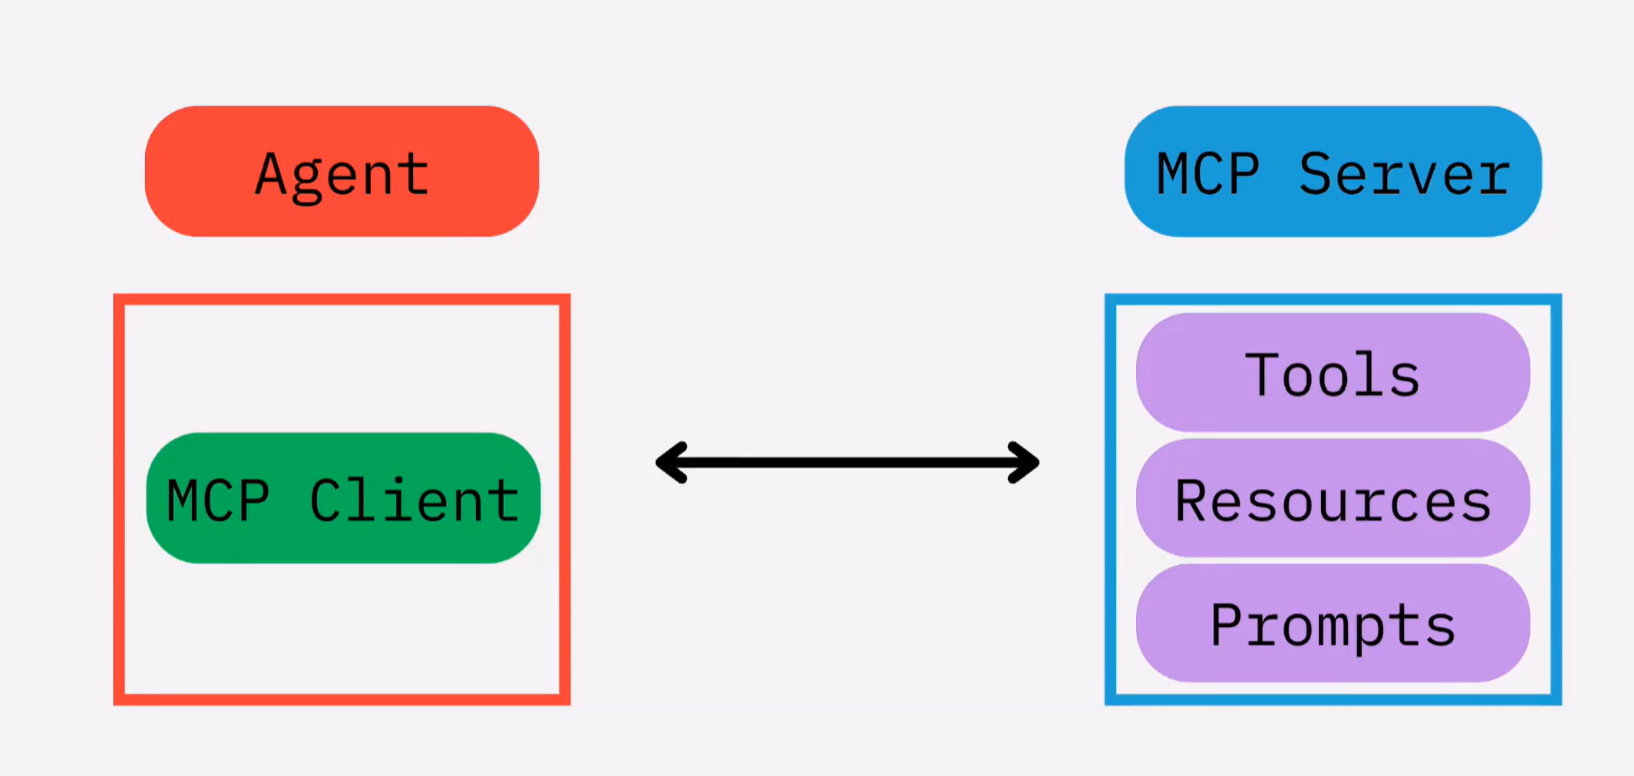
- Useful resources include [https://mcp.so/servers](https://mcp.so/servers)

In [15]:
# Another example of MCP Online Server (Kiwi Travel Server)

from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage

client = MultiServerMCPClient(
    {
        "travel_server": {
            "transport": "streamable_http",
            "url": "https://mcp.kiwi.com" # For the Kiwi MCP server, its tool is search-flight
        }
    }
)

tools = await client.get_tools()

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    checkpointer = InMemorySaver(),
    tools=tools,
    system_prompt="You are a travel agent. No follow up questions."
)

config = {"configurable": {"thread_id": "1"}}

response = await agent.ainvoke(
    {"messages": [HumanMessage(content="Get me a direct flight from San Francisco to Tokyo on March 31st")]},
    config
    )

from pprint import pprint
pprint(response)

{'messages': [HumanMessage(content='Get me a direct flight from San Francisco to Tokyo on March 31st', additional_kwargs={}, response_metadata={}, id='bbb5b934-644c-4afe-8efb-bf25dc28724a'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search-flight', 'arguments': '{"flyTo": "TYO", "departureDate": "31/03/2025", "flyFrom": "SFO"}'}, '__gemini_function_call_thought_signatures__': {'call_605459': 'EnMKcQFpFH0T+gCLXROA5CxmiUL6Gz/5mPetkzh4IM+TqkJd/uYfjObOO1ExIVxnIFqSnjrSkHsynnMM65UICaBq/S8YUGS7hOgA37xzQX3+cBfr13AUJjahWCfCJXlnLv3XjUvdHR5gPRkc7UImfamM4Kjj'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0f62e-e551-7660-89c7-90e46fd0b4a1-0', tool_calls=[{'name': 'search-flight', 'args': {'flyTo': 'TYO', 'departureDate': '31/03/2025', 'flyFrom': 'SFO'}, 'id': 'call_605459', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens'

In [17]:
print(response['messages'][-1].content[0]['text'])

Here are the available direct flight options from San Francisco (SFO) to Tokyo on March 31, 2027:

| Route | Times & Duration | Cabin | Price | Booking Link |
| :--- | :--- | :--- | :--- | :--- |
| **SFO → NRT** | 12:20 → 15:25 (11h 05m) | Economy | 451 EUR | [Book](https://kiwi.com/u/kqfnxm) |
| **SFO → HND** | 01:45 → 05:00 (11h 15m) | Economy | 457 EUR | [Book](https://kiwi.com/u/h7wrtrq) |

### Summary
*   **Best Price:** 451 EUR (via All Nippon Airways to Narita)
*   **Shortest Option:** 11h 05m (to Narita)

**Recommendation:** For the best value and travel time, the 11h 05m direct flight to Narita (NRT) is the most efficient choice.

Have a nice trip! **Fun Fact:** Tokyo has the most Michelin-starred restaurants of any city in the world, making it a true paradise for food lovers!
